# Crime Rate Predictor — NZ | EDA + Entraînement

**Dataset :** NZ Police — agressions, crimes sexuels et vols dans les lieux publics, 2015  
**Cible :** `Rate_per_10000_population` (taux de victimisations pour 10 000 habitants)  
**Famille ML :** Régression  
**Métrique principale :** MAE (crimes / 10 000 hab)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Chargement & nettoyage

- La colonne cible ` Rate_per_10000_population ` contient des espaces, des virgules ("1,199") et 417 lignes marquées `-` (données supprimées pour confidentialité statistique — zones avec ≤ 5 victimisations).  
- 126 lignes ont `Population_mid_point_2015 == 0` (zones non-résidentielles) → `log(0)` indéfini, on les exclut.

In [2]:
CSV_PATH = "analysis-public-place-assaults-sexual-assaults-and-robberies-2015-csv.csv"
df_raw = pd.read_csv(CSV_PATH)
print(f"Lignes brutes : {len(df_raw):,}  |  Colonnes : {df_raw.shape[1]}")

df = df_raw.copy()

# --- Nettoyage cible ---
rate_raw = df[" Rate_per_10000_population "].astype(str).str.strip().str.replace(",", "")
df["rate"] = pd.to_numeric(rate_raw.replace("-", None), errors="coerce")

n_suppressed = df["rate"].isna().sum()
n_pop0       = (df["Population_mid_point_2015"] == 0).sum()

df = df.dropna(subset=["rate"])
df = df[df["Population_mid_point_2015"] > 0].reset_index(drop=True)

# --- Features dérivées ---
df["Log_Population"] = np.log(df["Population_mid_point_2015"])
df["Is_Auckland"]    = df["Region_2013_label"].str.contains("Auckland").astype(int)

print(f"Lignes supprimées (taux '-') : {n_suppressed}")
print(f"Lignes pop=0                 : {n_pop0}")
print(f"Lignes utilisables           : {len(df):,}")
df.head(3)

Lignes brutes : 2,020  |  Colonnes : 14
Lignes supprimées (taux '-') : 417
Lignes pop=0                 : 126
Lignes utilisables           : 1,603


,Index,Area_unit_2013_code,Area_unit_2013_label,Victimisations_calendar_year_2015,Population_mid_point_2015,Rate_per_10000_population,Rate_ratio_NZ_average_rate,Urban_area_2013_code,Urban_area_2013_label,Urban_area_type,Territorial_authority_area_2013_code,Territorial_authority_area_2013_label,Region_2013_code,Region_2013_label,rate,Log_Population,Is_Auckland
0,1,514102,Auckland Central West,550,15900,346,6.6,4,Central Auckland Zone,Main urban area,76,Auckland,2,Auckland Region,346.0,9.674074,1
1,2,573101,Willis Street-Cambridge Terrace,447,8300,539,10.3,20,Wellington Zone,Main urban area,47,Wellington City,9,Wellington Region,539.0,9.024011,0
2,3,529700,Hamilton Central,380,3170,"1,199",22.9,6,Hamilton Zone,Main urban area,16,Hamilton City,3,Waikato Region,1199.0,8.061487,0


## 2. EDA — Distributions & outliers

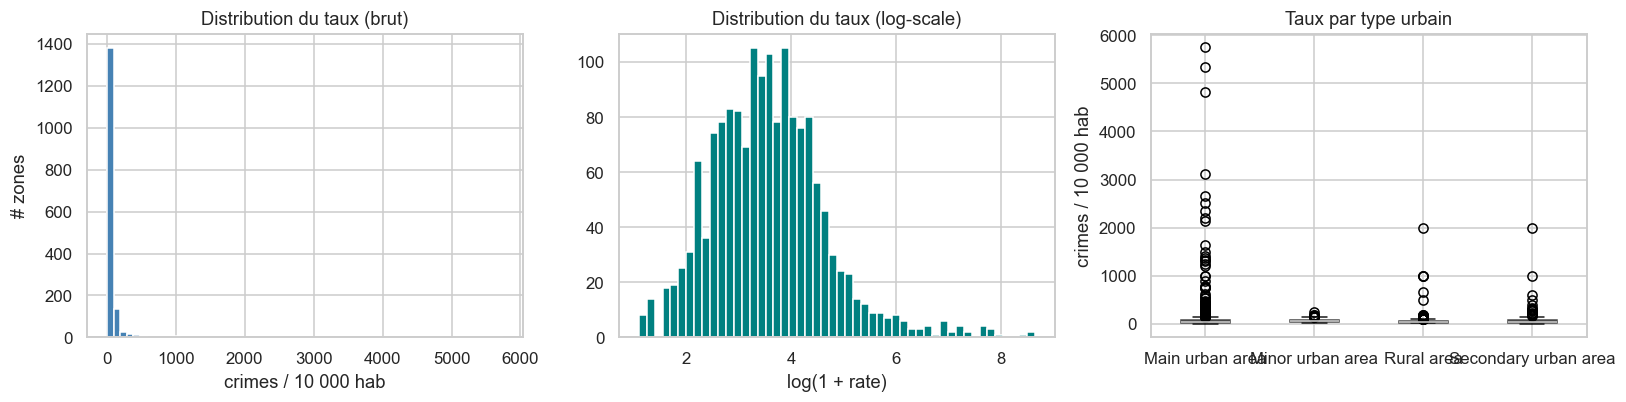

count    1603.0
mean       86.9
std       311.4
min         2.0
25%        16.0
50%        33.0
75%        65.0
max      5750.0
Name: rate, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution brute
axes[0].hist(df["rate"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution du taux (brut)")
axes[0].set_xlabel("crimes / 10 000 hab")
axes[0].set_ylabel("# zones")

# Distribution log
axes[1].hist(np.log1p(df["rate"]), bins=50, color="teal", edgecolor="white")
axes[1].set_title("Distribution du taux (log-scale)")
axes[1].set_xlabel("log(1 + rate)")

# Boxplot par urban type
df.boxplot(column="rate", by="Urban_area_type", ax=axes[2], patch_artist=True)
axes[2].set_title("Taux par type urbain")
axes[2].set_xlabel("")
axes[2].set_ylabel("crimes / 10 000 hab")
plt.suptitle("")

plt.tight_layout()
plt.show()
print(df["rate"].describe().round(1))

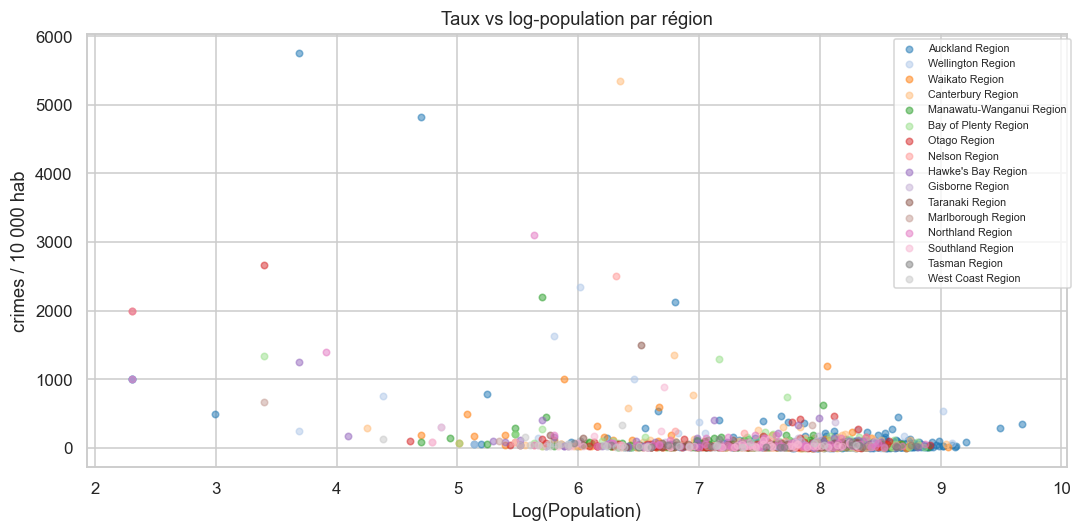

In [4]:
# Scatter Log_Population vs rate — coloré par région
fig, ax = plt.subplots(figsize=(10, 5))
regions = df["Region_2013_label"].unique()
palette = sns.color_palette("tab20", len(regions))
for reg, color in zip(regions, palette):
    mask = df["Region_2013_label"] == reg
    ax.scatter(df.loc[mask, "Log_Population"], df.loc[mask, "rate"],
               label=reg, color=color, alpha=0.5, s=18)

ax.set_xlabel("Log(Population)")
ax.set_ylabel("crimes / 10 000 hab")
ax.set_title("Taux vs log-population par région")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
plt.tight_layout()
plt.show()

Top 10 zones les plus criminogènes :
   Area_unit_2013_label        Region_2013_label Urban_area_type  Population_mid_point_2015   rate
              Highbrook          Auckland Region Main urban area                         40 5750.0
       Cathedral Square        Canterbury Region Main urban area                        570 5351.0
             Middlemore          Auckland Region Main urban area                        110 4818.0
      Whangarei Central         Northland Region Main urban area                        280 3107.0
            Harbourside             Otago Region Main urban area                         30 2667.0
              Trafalgar            Nelson Region Main urban area                        550 2509.0
        Porirua Central        Wellington Region Main urban area                        410 2341.0
          Cooks Gardens Manawatu-Wanganui Region Main urban area                        300 2200.0
        Manukau Central          Auckland Region Main urban area        

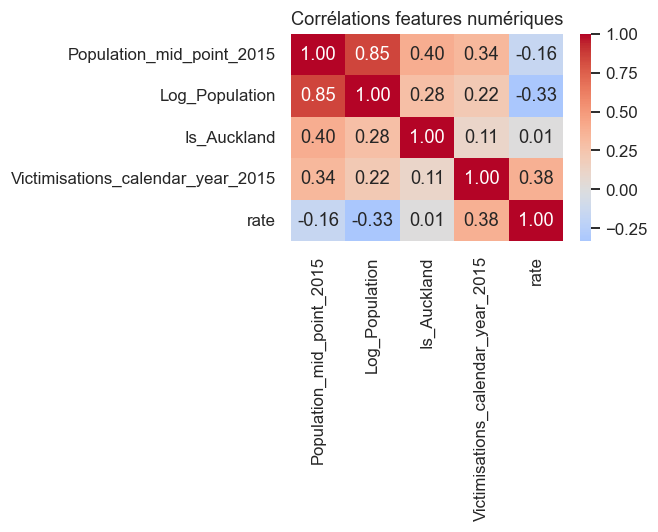

In [5]:
# Outliers — top 10 zones par taux
print("Top 10 zones les plus criminogènes :")
cols_show = ["Area_unit_2013_label", "Region_2013_label", "Urban_area_type",
             "Population_mid_point_2015", "rate"]
print(df.nlargest(10, "rate")[cols_show].to_string(index=False))

# Heatmap corrélations numériques
num_cols = ["Population_mid_point_2015", "Log_Population", "Is_Auckland",
            "Victimisations_calendar_year_2015", "rate"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Corrélations features numériques")
plt.tight_layout()
plt.show()

## 3. Préparation ML — Features, split, pipeline

**Features retenues (identiques au modèle P1) :**
- Numériques : `Population_mid_point_2015`, `Log_Population`, `Is_Auckland`
- Catégorielles : `Region_2013_label`, `Territorial_authority_area_2013_label`, `Urban_area_2013_label`, `Urban_area_type`

**Split :** 80/20, `random_state=42`  
**Anti-leakage :** tout le preprocessing est encapsulé dans le `Pipeline` → pas de `fit` avant le split.

In [6]:
NUM_FEATURES = ["Population_mid_point_2015", "Log_Population", "Is_Auckland"]
CAT_FEATURES = [
    "Region_2013_label",
    "Territorial_authority_area_2013_label",
    "Urban_area_2013_label",
    "Urban_area_type",
]
TARGET = "rate"

X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")

# Pipeline de preprocessing (anti-leakage : fit uniquement sur X_train)
num_transformer = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler()),
])
cat_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer([
    ("num", num_transformer, NUM_FEATURES),
    ("cat", cat_transformer, CAT_FEATURES),
])

Train : 1,282  |  Test : 321


## 4. Comparaison 3 modèles — CV 5-fold (neg_MAE)

LinearRegression        MAE = 101.7 ± 10.9


RandomForest            MAE = 75.7 ± 11.7


GradientBoosting        MAE = 73.6 ± 12.3


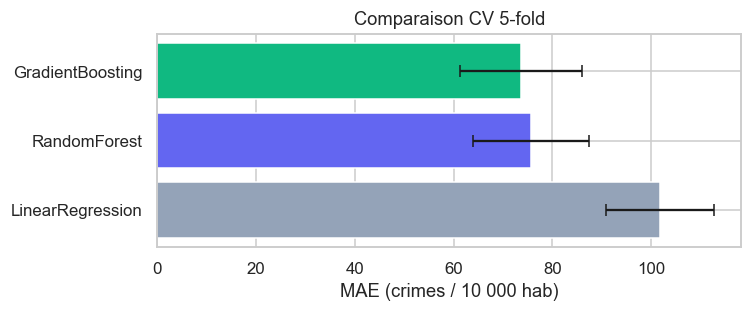

In [7]:
modeles = {
    "LinearRegression": LinearRegression(),
    "RandomForest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = {}
for nom, m in modeles.items():
    pipe = Pipeline([("prep", preprocessor), ("model", m)])
    scores = cross_val_score(
        pipe, X_train, y_train,
        scoring="neg_mean_absolute_error", cv=5, n_jobs=-1
    )
    results[nom] = {"mae_mean": -scores.mean(), "mae_std": scores.std()}
    print(f"{nom:22s}  MAE = {-scores.mean():.1f} ± {scores.std():.1f}")

# Barplot
fig, ax = plt.subplots(figsize=(7, 3))
names = list(results.keys())
means = [results[n]["mae_mean"] for n in names]
stds  = [results[n]["mae_std"]  for n in names]
colors = ["#94a3b8", "#6366f1", "#10b981"]
ax.barh(names, means, xerr=stds, color=colors, capsize=4)
ax.set_xlabel("MAE (crimes / 10 000 hab)")
ax.set_title("Comparaison CV 5-fold")
plt.tight_layout()
plt.show()

## 5. Tuning GradientBoosting — RandomizedSearchCV (n_iter=20)

In [8]:
pipeline_gbr = Pipeline([
    ("prep",  preprocessor),
    ("model", GradientBoostingRegressor(random_state=42)),
])

param_dist = {
    "model__n_estimators":  [100, 200, 300],
    "model__max_depth":     [3, 4, 5],
    "model__learning_rate": [0.05, 0.1, 0.15, 0.2],
    "model__subsample":     [0.8, 0.9, 1.0],
    "model__min_samples_leaf": [1, 2, 5],
}

search = RandomizedSearchCV(
    pipeline_gbr, param_dist,
    n_iter=20, scoring="neg_mean_absolute_error",
    cv=5, random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Meilleurs params :", search.best_params_)
print(f"Meilleur MAE CV  : {-search.best_score_:.1f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Meilleurs params : {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Meilleur MAE CV  : 73.2


## 6. Évaluation finale (test set — une seule fois) + export

MAE  test : 91.6 crimes / 10 000 hab
R²   test : 0.205


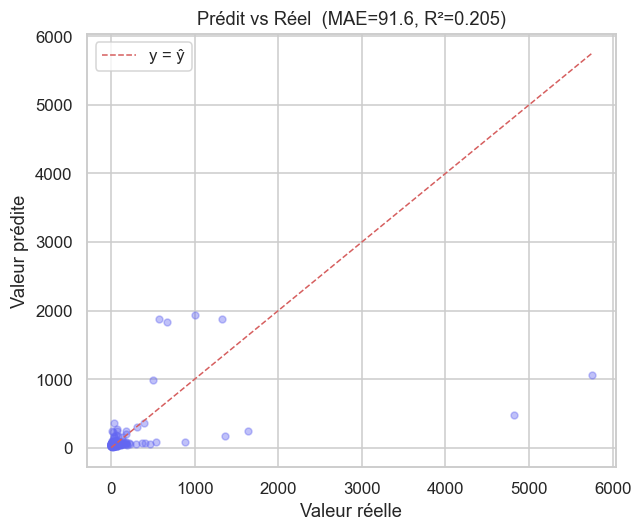

✅  Modèle exporté → backend/model.pkl

In [9]:
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"MAE  test : {mae:.1f} crimes / 10 000 hab")
print(f"R²   test : {r2:.3f}")

# Prédit vs réel
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.4, s=20, color="#6366f1")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="y = ŷ")
ax.set_xlabel("Valeur réelle")
ax.set_ylabel("Valeur prédite")
ax.set_title(f"Prédit vs Réel  (MAE={mae:.1f}, R²={r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

# Export
joblib.dump(best_pipeline, "backend/model.pkl")
print("✅  Modèle exporté → backend/model.pkl")